<a href="https://www.kaggle.com/code/ashutoshshrimishra/msme-credit-data-by-30s-cr-tensorflow-resmlp?scriptVersionId=295093586" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/msme-credit-data-by-30scr/MSME Credit Data by 30S-CR.xlsx
/kaggle/input/msme-credit-data-by-30scr/MSME Credit Data by 30S-CR_Data Description.xlsx


In [2]:
!pip install openpyxl

import os
import math
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from keras.layers import *
from category_encoders import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.3/251.3 kB 5.9 MB/s eta 0:00:00


In [3]:
df = pd.read_excel('/kaggle/input/msme-credit-data-by-30scr/MSME Credit Data by 30S-CR.xlsx')
df = df.drop(['Enterprise_id'], axis=1)
dfTrain = df.copy()

In [4]:
dfTrain

,Label,Registered_capital (Ten thousand Yuan),Province,Enterprise_type,Establishment_Duration (Days),Paid_in_capital (Ten thousand Yuan),Sector,SH_num,MS_num,CL_5years+,...,Legal_proceedings_num_3years,Legal_proceedings_num_2years,Legal_proceedings_num_1year,Filing_information_num_5years+,Filing_information_num_5years,Filing_information_num_4years,Filing_information_num_3years,Filing_information_num_2years,Filing_information_num_1years,Ratepaying_Credit_Grade_A_num
0,0,1200.0000,Sichuan,Limited liability company (Natural person inve...,1521.0,111.5967,Construction industry,2.0,2.0,0,...,0,0,0,0,0,0,0,0,0,1
1,0,5315.0000,Sichuan,Limited liability company (sole proprietorship...,1150.0,5315.0000,Construction industry,1.0,3.0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,5100.0000,Sichuan,Limited liability company (sole proprietorship...,1975.0,5100.0000,Construction industry,1.0,2.0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,2000.0000,Jiangxi,Limited liability company (Natural person inve...,778.0,0.0000,Construction industry,2.0,2.0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,5700.0000,Hubei,Other joint stock limited companies (unlisted),8187.0,5033.2300,Scientific research and technology services,17.0,8.0,3,...,3,8,4,0,1,1,3,3,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1702,1,3000.0000,Hunan,Limited liability company (Natural person inve...,4730.0,1570.0000,Manufacturing,2.0,2.0,5,...,0,0,0,0,0,0,0,0,0,1
1703,1,1002.0000,Hunan,Limited liability company (Natural person inve...,6678.0,502.0000,Wholesale and retail,2.0,2.0,2,...,3,0,3,0,0,2,1,0,3,3
1704,1,5009.4233,Hebei,Other joint stock limited companies (unlisted),3945.0,1010.0000,Wholesale and retail,33.0,12.0,36,...,0,1,6,0,0,0,0,0,3,0
1705,1,100000.0000,Hunan,Limited liability company (Natural person inve...,4516.0,0.0000,Leasing and business services,2.0,2.0,0,...,0,1,0,0,0,2,1,0,0,2


In [5]:
dfTrain_obj = dfTrain.select_dtypes(include=['object'])
dfTrain_obj

,Province,Enterprise_type,Sector
0,Sichuan,Limited liability company (Natural person inve...,Construction industry
1,Sichuan,Limited liability company (sole proprietorship...,Construction industry
2,Sichuan,Limited liability company (sole proprietorship...,Construction industry
3,Jiangxi,Limited liability company (Natural person inve...,Construction industry
4,Hubei,Other joint stock limited companies (unlisted),Scientific research and technology services
...,...,...,...
1702,Hunan,Limited liability company (Natural person inve...,Manufacturing
1703,Hunan,Limited liability company (Natural person inve...,Wholesale and retail
1704,Hebei,Other joint stock limited companies (unlisted),Wholesale and retail
1705,Hunan,Limited liability company (Natural person inve...,Leasing and business services


In [6]:
dfTrain_obj.Province.replace({k: v for k, v in zip(dfTrain_obj.Province.unique(), list(range(len(dfTrain_obj.Province.unique()))))}, inplace=True)
dfTrain_obj

/opt/conda/lib/python3.7/site-packages/pandas/core/generic.py:6619: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return self._update_inplace(result)


,Province,Enterprise_type,Sector
0,0,Limited liability company (Natural person inve...,Construction industry
1,0,Limited liability company (sole proprietorship...,Construction industry
2,0,Limited liability company (sole proprietorship...,Construction industry
3,1,Limited liability company (Natural person inve...,Construction industry
4,2,Other joint stock limited companies (unlisted),Scientific research and technology services
...,...,...,...
1702,10,Limited liability company (Natural person inve...,Manufacturing
1703,10,Limited liability company (Natural person inve...,Wholesale and retail
1704,7,Other joint stock limited companies (unlisted),Wholesale and retail
1705,10,Limited liability company (Natural person inve...,Leasing and business services


In [7]:
lb = LabelEncoder()
dfTrain_obj['Enterprise_type'] = lb.fit_transform(dfTrain_obj['Enterprise_type'])
dfTrain_obj['Sector'] = lb.fit_transform(dfTrain_obj['Sector'])

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  
/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  This is separate from the ipykernel package so we can avoid doing imports until


In [8]:
dfTrain_obj

,Province,Enterprise_type,Sector
0,0,3,1
1,0,7,1
2,0,7,1
3,1,3,1
4,2,9,10
...,...,...,...
1702,10,3,6
1703,10,3,13
1704,7,9,13
1705,10,3,5


In [9]:
dfTrain_obj.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1707 entries, 0 to 1706
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Province         1707 non-null   int64
 1   Enterprise_type  1707 non-null   int64
 2   Sector           1707 non-null   int64
dtypes: int64(3)
memory usage: 40.1 KB


In [10]:
dfTrain_int = dfTrain.select_dtypes(include=['int64'])
dfTrain_int

,Label,CL_5years+,CL_5years,CL_4years,CL_3years,CL_2years,CL_1year,Certificate_num_5years+,Certificate_num_5years,Certificate_num_4years,...,Legal_proceedings_num_3years,Legal_proceedings_num_2years,Legal_proceedings_num_1year,Filing_information_num_5years+,Filing_information_num_5years,Filing_information_num_4years,Filing_information_num_3years,Filing_information_num_2years,Filing_information_num_1years,Ratepaying_Credit_Grade_A_num
0,0,0,0,2,0,1,2,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,0,0,0,0,2,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,3,0,3,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,2,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,3,0,0,0,5,1,0,1,8,...,3,8,4,0,1,1,3,3,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1702,1,5,2,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1703,1,2,0,0,0,0,0,0,0,0,...,3,0,3,0,0,2,1,0,3,3
1704,1,36,0,3,14,0,0,0,0,0,...,0,1,6,0,0,0,0,0,3,0
1705,1,0,0,1,16,2,34,0,0,0,...,0,1,0,0,0,2,1,0,0,2


In [11]:
dfTrain_float = dfTrain.select_dtypes(include=['float64'])
dfTrain_float = dfTrain_float.fillna(1)
dfTrain_float

,Registered_capital (Ten thousand Yuan),Establishment_Duration (Days),Paid_in_capital (Ten thousand Yuan),SH_num,MS_num,Branch_num,t-1 Basic old-age insurance for urban employees,t-2 Basic old-age insurance for urban employees,t-3 Basic old-age insurance for urban employees,t-1 Unemployment insurance,...,t-3 Unemployment insurance,t-1 Basic medical insurance for employees,t-2 Basic medical insurance for employees,t-3 Basic medical insurance for employees,t-1 Employment injury insurance,t-2 Employment injury insurance,t-3 Employment injury insurance,t-1 Birth insurance,t-2 Birth insurance,t-3 Birth insurance
0,1200.0000,1521.0,111.5967,2.0,2.0,1.0,9.0,18.0,0.0,9.0,...,0.0,9.0,18.0,0.0,0.0,18.0,0.0,9.0,18.0,0.0
1,5315.0000,1150.0,5315.0000,1.0,3.0,1.0,14.0,6.0,3.0,14.0,...,3.0,14.0,6.0,3.0,14.0,6.0,3.0,14.0,6.0,3.0
2,5100.0000,1975.0,5100.0000,1.0,2.0,1.0,20.0,22.0,23.0,20.0,...,23.0,20.0,22.0,23.0,20.0,22.0,23.0,20.0,22.0,23.0
3,2000.0000,778.0,0.0000,2.0,2.0,3.0,4.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
4,5700.0000,8187.0,5033.2300,17.0,8.0,9.0,91.0,105.0,105.0,91.0,...,105.0,91.0,105.0,108.0,91.0,100.0,105.0,91.0,105.0,108.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1702,3000.0000,4730.0,1570.0000,2.0,2.0,1.0,0.0,11.0,11.0,0.0,...,11.0,0.0,11.0,11.0,0.0,11.0,11.0,0.0,11.0,11.0
1703,1002.0000,6678.0,502.0000,2.0,2.0,3.0,23.0,23.0,19.0,23.0,...,19.0,23.0,23.0,19.0,23.0,23.0,19.0,23.0,23.0,19.0
1704,5009.4233,3945.0,1010.0000,33.0,12.0,14.0,209.0,284.0,271.0,210.0,...,272.0,197.0,284.0,243.0,214.0,286.0,273.0,197.0,284.0,243.0
1705,100000.0000,4516.0,0.0000,2.0,2.0,2.0,15.0,50.0,18.0,15.0,...,182.0,0.0,0.0,0.0,15.0,200.0,182.0,0.0,0.0,0.0


In [12]:
for col in dfTrain_float.columns.tolist():
    dfTrain_float[col][dfTrain_float[col] == 0] = 1
    dfTrain_float[col] = round(np.log2(dfTrain_float[col]), 0)

In [13]:
dfTrain_float

,Registered_capital (Ten thousand Yuan),Establishment_Duration (Days),Paid_in_capital (Ten thousand Yuan),SH_num,MS_num,Branch_num,t-1 Basic old-age insurance for urban employees,t-2 Basic old-age insurance for urban employees,t-3 Basic old-age insurance for urban employees,t-1 Unemployment insurance,...,t-3 Unemployment insurance,t-1 Basic medical insurance for employees,t-2 Basic medical insurance for employees,t-3 Basic medical insurance for employees,t-1 Employment injury insurance,t-2 Employment injury insurance,t-3 Employment injury insurance,t-1 Birth insurance,t-2 Birth insurance,t-3 Birth insurance
0,10.0,11.0,7.0,1.0,1.0,0.0,3.0,4.0,0.0,3.0,...,0.0,3.0,4.0,0.0,0.0,4.0,0.0,3.0,4.0,0.0
1,12.0,10.0,12.0,0.0,2.0,0.0,4.0,3.0,2.0,4.0,...,2.0,4.0,3.0,2.0,4.0,3.0,2.0,4.0,3.0,2.0
2,12.0,11.0,12.0,0.0,1.0,0.0,4.0,4.0,5.0,4.0,...,5.0,4.0,4.0,5.0,4.0,4.0,5.0,4.0,4.0,5.0
3,11.0,10.0,0.0,1.0,1.0,2.0,2.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,12.0,13.0,12.0,4.0,3.0,3.0,7.0,7.0,7.0,7.0,...,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1702,12.0,12.0,11.0,1.0,1.0,0.0,0.0,3.0,3.0,0.0,...,3.0,0.0,3.0,3.0,0.0,3.0,3.0,0.0,3.0,3.0
1703,10.0,13.0,9.0,1.0,1.0,2.0,5.0,5.0,4.0,5.0,...,4.0,5.0,5.0,4.0,5.0,5.0,4.0,5.0,5.0,4.0
1704,12.0,12.0,10.0,5.0,4.0,4.0,8.0,8.0,8.0,8.0,...,8.0,8.0,8.0,8.0,8.0,8.0,8.0,8.0,8.0,8.0
1705,17.0,12.0,0.0,1.0,1.0,1.0,4.0,6.0,4.0,4.0,...,8.0,0.0,0.0,0.0,4.0,8.0,8.0,0.0,0.0,0.0


In [14]:
dfMerge = pd.concat([dfTrain_obj, dfTrain_float, dfTrain_int.iloc[:, 1:]], axis=1)
dfMerge

,Province,Enterprise_type,Sector,Registered_capital (Ten thousand Yuan),Establishment_Duration (Days),Paid_in_capital (Ten thousand Yuan),SH_num,MS_num,Branch_num,t-1 Basic old-age insurance for urban employees,...,Legal_proceedings_num_3years,Legal_proceedings_num_2years,Legal_proceedings_num_1year,Filing_information_num_5years+,Filing_information_num_5years,Filing_information_num_4years,Filing_information_num_3years,Filing_information_num_2years,Filing_information_num_1years,Ratepaying_Credit_Grade_A_num
0,0,3,1,10.0,11.0,7.0,1.0,1.0,0.0,3.0,...,0,0,0,0,0,0,0,0,0,1
1,0,7,1,12.0,10.0,12.0,0.0,2.0,0.0,4.0,...,0,0,0,0,0,0,0,0,0,0
2,0,7,1,12.0,11.0,12.0,0.0,1.0,0.0,4.0,...,0,0,0,0,0,0,0,0,0,0
3,1,3,1,11.0,10.0,0.0,1.0,1.0,2.0,2.0,...,0,0,0,0,0,0,0,0,0,0
4,2,9,10,12.0,13.0,12.0,4.0,3.0,3.0,7.0,...,3,8,4,0,1,1,3,3,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1702,10,3,6,12.0,12.0,11.0,1.0,1.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,1
1703,10,3,13,10.0,13.0,9.0,1.0,1.0,2.0,5.0,...,3,0,3,0,0,2,1,0,3,3
1704,7,9,13,12.0,12.0,10.0,5.0,4.0,4.0,8.0,...,0,1,6,0,0,0,0,0,3,0
1705,10,3,5,17.0,12.0,0.0,1.0,1.0,1.0,4.0,...,0,1,0,0,0,2,1,0,0,2


In [15]:
X = np.array(dfMerge)
y = np.asarray(dfTrain_int.Label).astype('int64')

In [16]:
X.shape

(1707, 87)

In [17]:
y.shape

(1707,)

In [18]:
def create_dataset(X_data, y_data):
    X_train, X_test, y_train, y_test = train_test_split(X_data, y_data)
    sc = MinMaxScaler()
    X_train = sc.fit_transform(X_train)
    X_test = sc.transform(X_test)
    
    X_train = tf.cast(X_train, tf.float32)
    X_test = tf.cast(X_test, tf.float32)
    y_train = tf.cast(y_train, tf.int64)
    y_test = tf.cast(y_test, tf.int64)
    
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = create_dataset(X, y)

In [19]:
def GELU(x):
    res = 0.5 * x * (1 + tf.nn.tanh(math.sqrt(2 / math.pi) * (x + 0.044715 * (x ** 3))))
    return res



class ResMLPBlock(tf.keras.layers.Layer):
    def __init__(self, units, residual_path):
        super(ResMLPBlock, self).__init__()
        self.residual_path = residual_path
        self.D1 = Dense(units, activation='relu')
        self.D2 = Dense(units, activation='relu')

        if self.residual_path:
            self.D3 = Dense(units)
            self.D4 = Dense(units)

    def call(self, inputs):
        residual = inputs

        x = self.D1(inputs)
        y = self.D2(x)

        if self.residual_path:
            residual = self.D3(inputs)
            residual = GELU(residual)
            residual = self.D4(residual)
            residual = GELU(residual)

        output = y + residual
        return output


# ResMLP网络结构
class ResMLP(tf.keras.Model):
    def __init__(self, initial_filters, block_list, num_classes):
        super(ResMLP, self).__init__()
        self.initial_filters = initial_filters
        self.block_list = block_list

        self.D1 = Dense(self.initial_filters, activation='relu')
        self.B1 = BatchNormalization()

        self.blocks = tf.keras.models.Sequential()
        for block_id in range(len(block_list)):
            for layer_id in range(block_list[block_id]):
                if block_id != 0 and layer_id == 0:
                    block = ResMLPBlock(units=self.initial_filters, residual_path=True)
                else:
                    block = ResMLPBlock(units=self.initial_filters, residual_path=False)
                self.blocks.add(block)
            self.initial_filters *= 2

        self.D2 = Dense(num_classes, activation='softmax')


    def call(self, inputs):
        x = self.D1(inputs)
        x = self.B1(x)
        x = self.blocks(x)
        y = self.D2(x)
        return y

In [20]:
net = ResMLP(initial_filters=64, block_list=[3, 4, 6, 3], num_classes=2)

net.compile(optimizer='adam',
            loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
            metrics=['sparse_categorical_accuracy'])

checkpoint_save_path = './checkpoint/ResMLP.ckpt'
if os.path.exists(checkpoint_save_path + '.index'):
    print('-------------------------------------Loading-------------------------------------')
    net.load_weights(checkpoint_save_path)

cp_callback = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_save_path,
                                                 save_weights_only=True,
                                                 save_best_only=True)

early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, min_delta=1e-4)

history = net.fit(X_train, y_train, batch_size=32, epochs=30, validation_data=(X_test, y_test), callbacks=[cp_callback, early_stopping])

net.summary()

file = open('./weights.txt', 'w')
for v in net.trainable_variables:
    file.write(str(v.name) + '\n')
    file.write(str(v.shape) + '\n')
    file.write(str(v.numpy()) + '\n')
file.close()

Epoch 1/30
40/40 [==============================] - 6s 65ms/step - loss: 2.4186 - sparse_categorical_accuracy: 0.9039 - val_loss: 0.2873 - val_sparse_categorical_accuracy: 0.9485
Epoch 2/30
40/40 [==============================] - 2s 46ms/step - loss: 0.2201 - sparse_categorical_accuracy: 0.9375 - val_loss: 0.2513 - val_sparse_categorical_accuracy: 0.9485
Epoch 3/30
40/40 [==============================] - 2s 43ms/step - loss: 0.1879 - sparse_categorical_accuracy: 0.9383 - val_loss: 0.2742 - val_sparse_categorical_accuracy: 0.9485
Epoch 4/30
40/40 [==============================] - 2s 41ms/step - loss: 0.1858 - sparse_categorical_accuracy: 0.9398 - val_loss: 0.2592 - val_sparse_categorical_accuracy: 0.9485
Epoch 5/30
40/40 [==============================] - 2s 42ms/step - loss: 0.1518 - sparse_categorical_accuracy: 0.9500 - val_loss: 0.2919 - val_sparse_categorical_accuracy: 0.9485
Epoch 6/30
40/40 [==============================] - 2s 40ms/step - loss: 0.1217 - sparse_categorical_accu

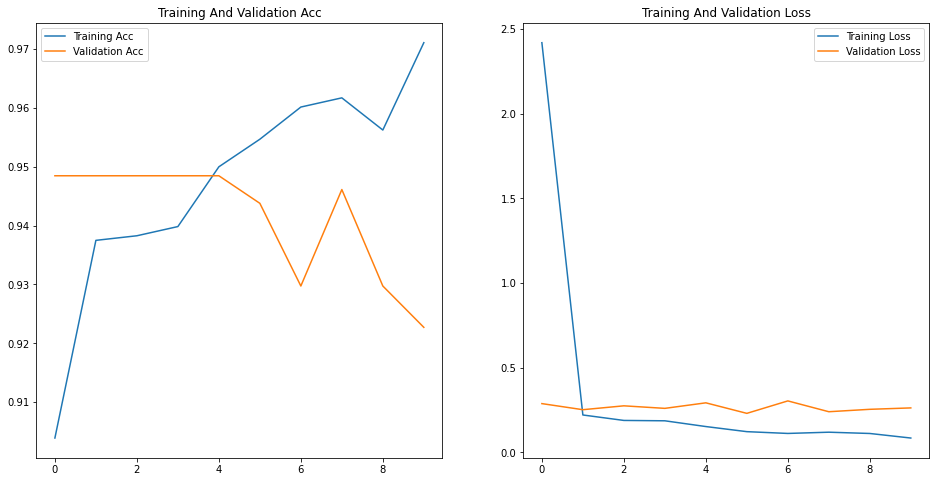

In [21]:
acc = history.history['sparse_categorical_accuracy']
val_acc = history.history['val_sparse_categorical_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Acc')
plt.plot(val_acc, label='Validation Acc')
plt.title('Training And Validation Acc')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Training And Validation Loss')

plt.legend()
plt.show()